<a href="https://colab.research.google.com/github/manjunath1005/celebal-excellence-internship/blob/main/week2_Manjunath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Problem

The goal of this project is to analyze Tesla delivery data and build machine learning models to predict vehicle deliveries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## 1. Data Loading

Dataset Source:
https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025

Download the dataset and place it in the same directory as the notebook before execution.


In [2]:
df = pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 2. Dataset Overview

Before modeling, the dataset is checked for:
- Data types
- Missing values
- Duplicate records
- Basic statistics

In [3]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [4]:
print("Missing Values Per Column:")
df.isnull().sum()

Missing Values Per Column:


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [5]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [6]:
print("Dataset Description :")

df.describe()

Dataset Description :


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## 3. Exploratory Data Analysis

The dataset was explored to understand delivery trends, regional performance, model popularity, and relationships between key variables.

Questions :

- How have deliveries changed over time?
- Which regions contribute the most deliveries?
- Which Tesla models are most popular?
- How are the numerical features related?
- What is the relationship between production and deliveries?

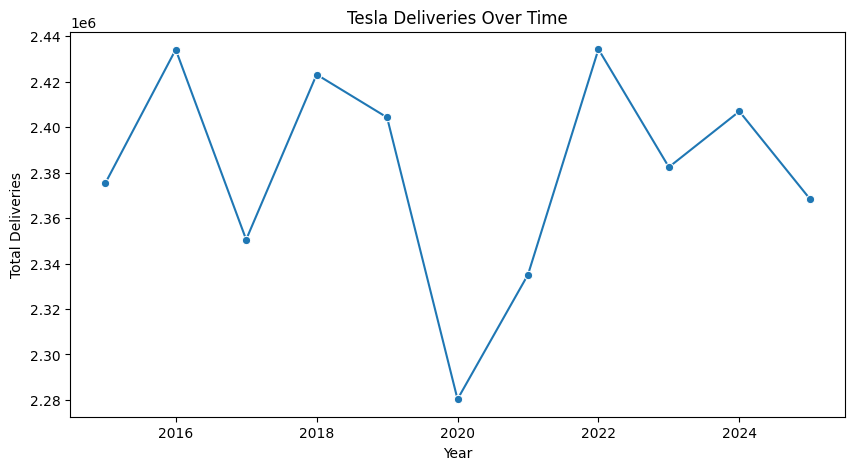

In [7]:
yearly_deliveries = df.groupby("Year")["Estimated_Deliveries"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_deliveries, x="Year", y="Estimated_Deliveries", marker="o")
plt.title("Tesla Deliveries Over Time")
plt.ylabel("Total Deliveries")
plt.xlabel("Year")
plt.show()

**Observation:**
- Yearly deliveries fluctuate over time.
- No strong long-term upward or downward trend is observed.

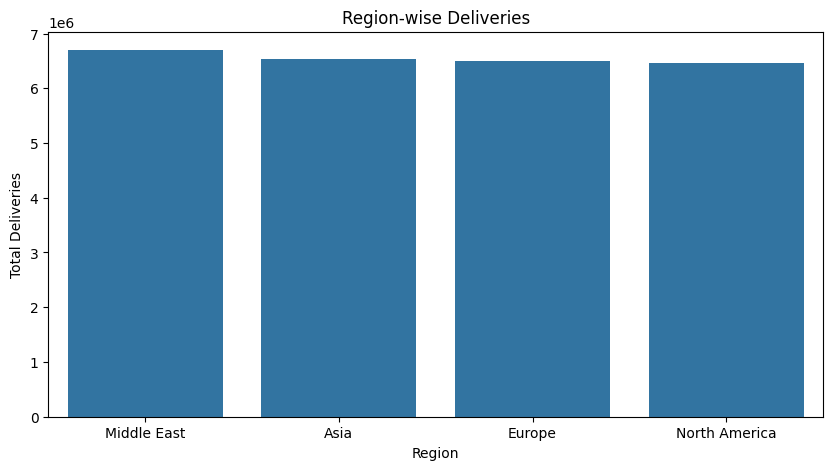

In [8]:
region_deliveries = df.groupby("Region")["Estimated_Deliveries"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=region_deliveries.index, y=region_deliveries.values)
plt.title("Region-wise Deliveries")
plt.ylabel("Total Deliveries")
plt.xlabel("Region")
plt.show()

**Observation:**
Deliveries are relatively balanced across regions.

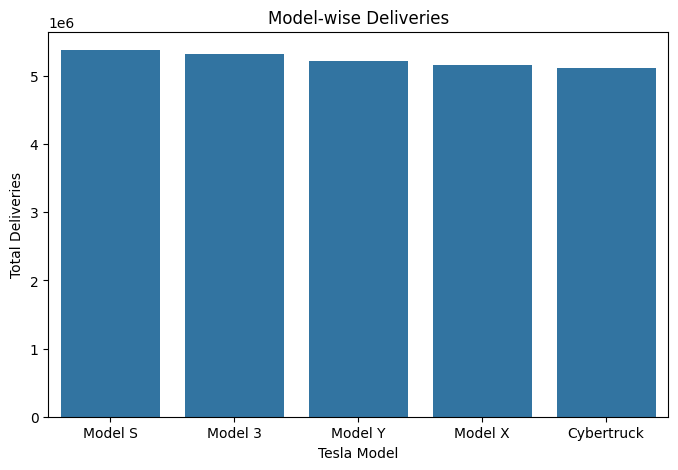

In [9]:
model_deliveries = df.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=model_deliveries.index,y=model_deliveries.values)
plt.title("Model-wise Deliveries")
plt.ylabel("Total Deliveries")
plt.xlabel("Tesla Model")
plt.show()

**Observation:**
Model S has the highest deliveries

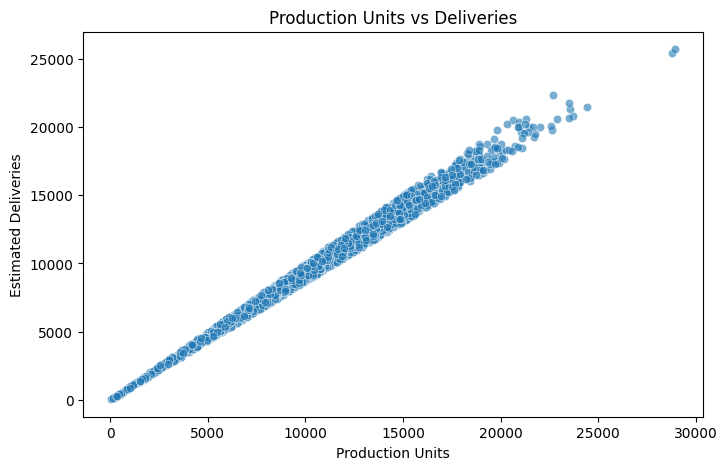

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Production_Units", y="Estimated_Deliveries", alpha=0.6)
plt.title("Production Units vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.show()

**Observation:**
- Production Units and Deliveries show a strong positive relationship.
- This suggests Production Units may be an important predictor.

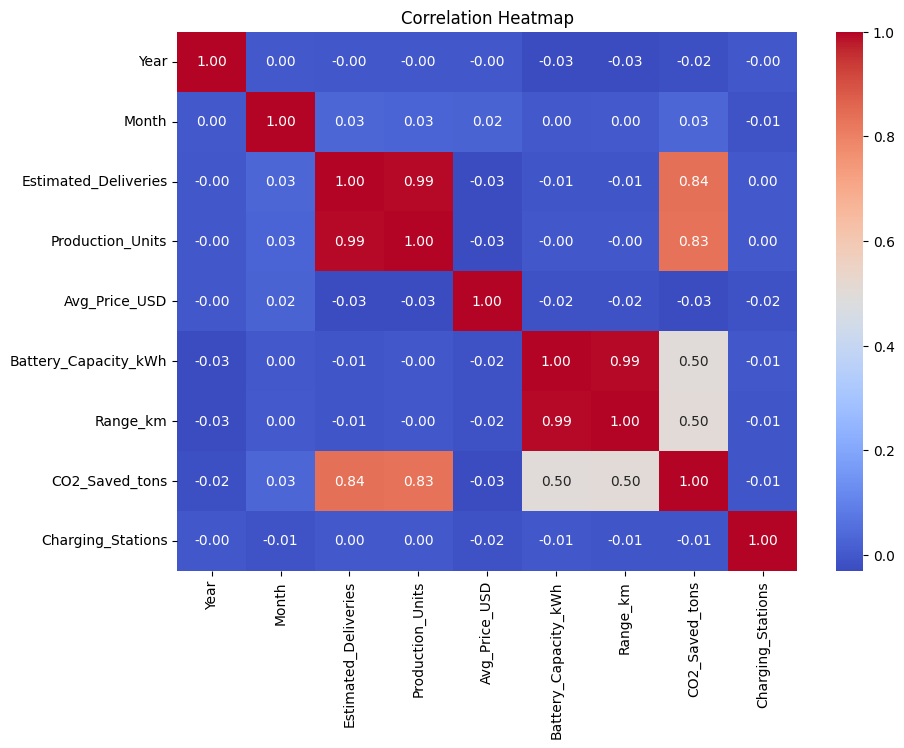

In [11]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**EDA Insights :**
- Production Units have the strongest relationship with Deliveries.
- CO2 Savings are positively related to Deliveries.
- Battery Capacity and Range are strongly related.
- Price has a weak relationship with Deliveries.

# 4. Feature Engineering

Categorical features were converted into numerical form using One-Hot Encoding.

These transformed features were used for model training.

## 5. Data Preparation for Machine Learning

The dataset is split into features and target.

Categorical features are encoded and numerical features are scaled using a preprocessing pipeline.

In [12]:
X = df.drop("Estimated_Deliveries", axis=1)
y = df["Estimated_Deliveries"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (2640, 11)
Target Shape : (2640,)


In [13]:
categorical_features = ["Region", "Model", "Source_Type"]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Region', 'Model', 'Source_Type']

Numerical Features:
['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (2112, 11)
Testing Set : (528, 11)


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

## 6. Linear Regression

In [16]:
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_pipeline.fit(X_train, y_train)
y_pred_lr = linear_pipeline.predict(X_test)

In [17]:
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name}:")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    return [model_name, mae, rmse, r2]

In [18]:
results = []

results.append(evaluate_model(y_test, y_pred_lr, "Linear Regression"))


Linear Regression:
MAE  : 309.70
RMSE : 384.03
R²   : 0.9901


## 7. Ridge Regression

In [19]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1))
    ]
)

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

In [20]:
results.append(evaluate_model(y_test, y_pred_ridge, "Ridge Regression"))


Ridge Regression:
MAE  : 309.53
RMSE : 384.07
R²   : 0.9901


## 8. Lasso Regression

In [21]:
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=0.1))
    ]
)

lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)

In [22]:
results.append(evaluate_model(y_test, y_pred_lasso, "Lasso Regression"))


Lasso Regression:
MAE  : 309.66
RMSE : 383.86
R²   : 0.9901


**Linear Model Comparison :**
- Linear Regression, Ridge, and Lasso produced very similar results.

- This indicates that regularization had little effect on model performance.

## 9. Random Forest Regression

In [23]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

In [24]:
results.append(evaluate_model(y_test, y_pred_rf, "Random Forest"))


Random Forest:
MAE  : 322.62
RMSE : 407.89
R²   : 0.9888


## 10. XGBoost Regression

In [25]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                random_state=42
            )
        )
    ]
)

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

In [26]:
results.append(evaluate_model(y_test, y_pred_xgb, "XGBoost"))


XGBoost:
MAE  : 300.27
RMSE : 370.03
R²   : 0.9908


In [27]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

results_df = results_df.sort_values(by="R2",ascending=False)
results_df

,Model,MAE,RMSE,R2
4,XGBoost,300.268311,370.029391,0.990815
2,Lasso Regression,309.661353,383.860460,0.990115
0,Linear Regression,309.703674,384.029115,0.990106
1,Ridge Regression,309.529486,384.068592,0.990104
3,Random Forest,322.616487,407.894006,0.988838


**Model Comparison :**
XGBoost achieved the best performance among all regression models.

## 11. Hyperparameter Tuning

Grid Search CV was used to find the best XGBoost parameters.

In [28]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            random_state=42
        ))
    ]
)

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Year',
                                                                          'Month',
                                                                          'Production_Units',
                                                                          'Avg_Price_USD',
                                                                          'Battery_Capacity_kWh',
                                                                          'Range_km',
                                                                          'CO2_Saved_tons',
                                                                          'Charging_Stations']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type'])])),
                                       ('model',
                                        XGBRegressor(base_...
                                                     max_cat_threshold=None,
                                                     max_cat_to_onehot=None,
                                                     max_delta_step=None,
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [3, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

In [29]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

Best Cross Validation Score:
0.9916371464729309


In [30]:
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

evaluate_model(y_test, y_pred_best, "Tuned XGBoost")


Tuned XGBoost:
MAE  : 243.14
RMSE : 316.74
R²   : 0.9933


['Tuned XGBoost',
 243.14488220214844,
 np.float64(316.74146594659817),
 0.9932696223258972]

### Actual vs Predicted Deliveries

The scatter plot compares actual delivery values with model predictions.

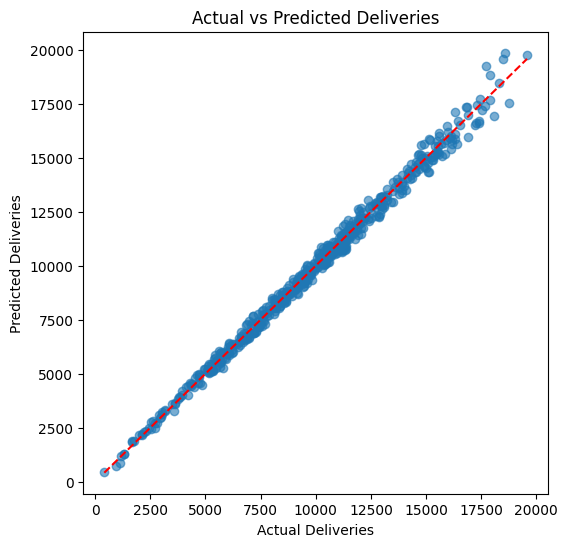

In [31]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")
plt.show()

## 12. Feature Importance

In [32]:
best_xgb_model = best_xgb.named_steps["model"]
feature_names = (best_xgb.named_steps["preprocessor"].get_feature_names_out())

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb_model.feature_importances_
})

importance_df = (importance_df.sort_values("Importance", ascending=False))
importance_df.head(15)

,Feature,Importance
2,num__Production_Units,0.955329
19,cat__Source_Type_Official (Quarter),0.006861
6,num__CO2_Saved_tons,0.004806
5,num__Range_km,0.004367
4,num__Battery_Capacity_kWh,0.003150
16,cat__Model_Model Y,0.002782
17,cat__Source_Type_Estimated (Region),0.002428
18,cat__Source_Type_Interpolated (Month),0.002304
3,num__Avg_Price_USD,0.002175
9,cat__Region_Europe,0.002159


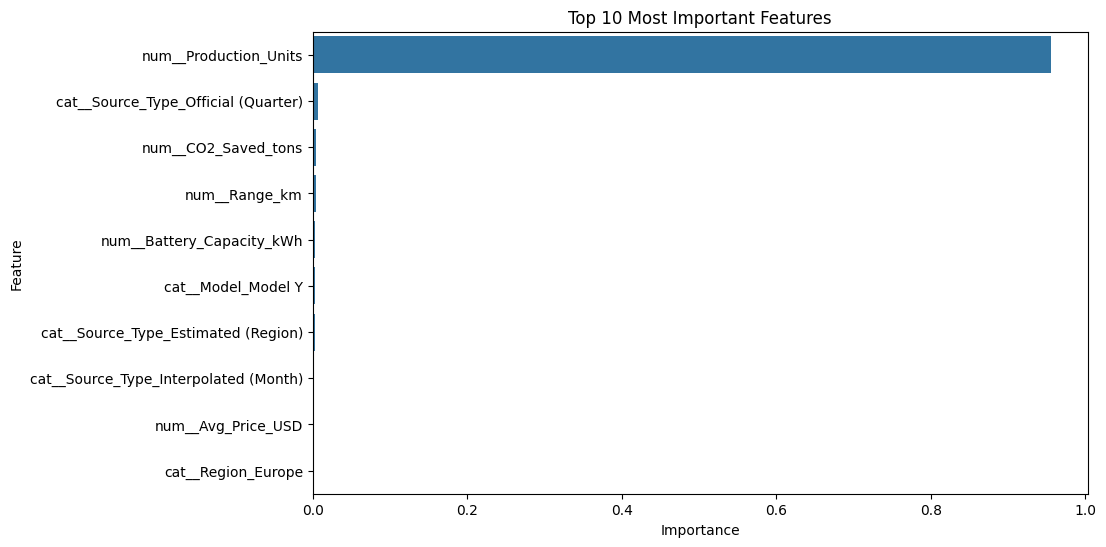

In [33]:
plt.figure(figsize=(10,6))

top_features = importance_df.head(10)
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 10 Most Important Features")
plt.show()

**Feature Importance Insights**:

- Production Units are the most important feature for predicting deliveries.

- Other features contribute much less to the prediction.

# 13. Time Series Forecasting

Forecasting models were used to predict future deliveries based on historical data.

In [34]:
ts_df = (df.groupby(["Year", "Month"])["Estimated_Deliveries"].sum().reset_index())

ts_df["Date"] = pd.to_datetime(
    ts_df["Year"].astype(str)
    + "-"
    + ts_df["Month"].astype(str)
)

ts_df = ts_df.sort_values("Date")

ts_df.head()

,Year,Month,Estimated_Deliveries,Date
0,2015,1,183180,2015-01-01
1,2015,2,165053,2015-02-01
2,2015,3,184567,2015-03-01
3,2015,4,225623,2015-04-01
4,2015,5,184264,2015-05-01


In [35]:
print("Number of Monthly Observations:")
print(len(ts_df))

ts_df.tail()

Number of Monthly Observations:
132


,Year,Month,Estimated_Deliveries,Date
127,2025,8,214357,2025-08-01
128,2025,9,193337,2025-09-01
129,2025,10,178964,2025-10-01
130,2025,11,197146,2025-11-01
131,2025,12,209391,2025-12-01


### Monthly Deliveries Trend

Monthly deliveries are plotted to observe patterns over time.

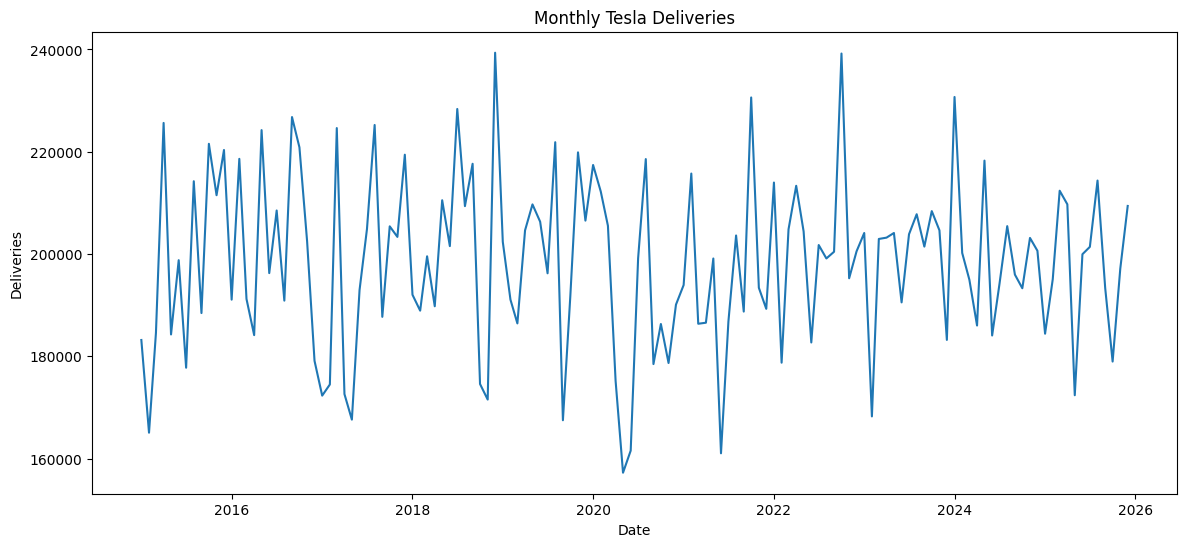

In [36]:
plt.figure(figsize=(14,6))

plt.plot(ts_df["Date"], ts_df["Estimated_Deliveries"])
plt.title("Monthly Tesla Deliveries")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.show()

In [37]:
train_ts = ts_df.iloc[:-12]
test_ts = ts_df.iloc[-12:]

print("Training Observations :", len(train_ts))
print("Testing Observations  :", len(test_ts))

Training Observations : 120
Testing Observations  : 12


**Forecasting Strategy :**
The last 12 months were used for testing and the remaining data was used for training.

### Holt-Winters Forecast

The Holt-Winters model was used to forecast future deliveries and compare predictions with actual values.

In [38]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [39]:
hw_model = ExponentialSmoothing(
    train_ts["Estimated_Deliveries"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

hw_fit = hw_model.fit()

In [40]:
hw_forecast = hw_fit.forecast(12)

forecast_mae = mean_absolute_error(test_ts["Estimated_Deliveries"], hw_forecast)
forecast_rmse = np.sqrt(mean_squared_error(test_ts["Estimated_Deliveries"],hw_forecast))

print("Forecast MAE :", round(forecast_mae,2))
print("Forecast RMSE:", round(forecast_rmse,2))

Forecast MAE : 10494.59
Forecast RMSE: 13871.7


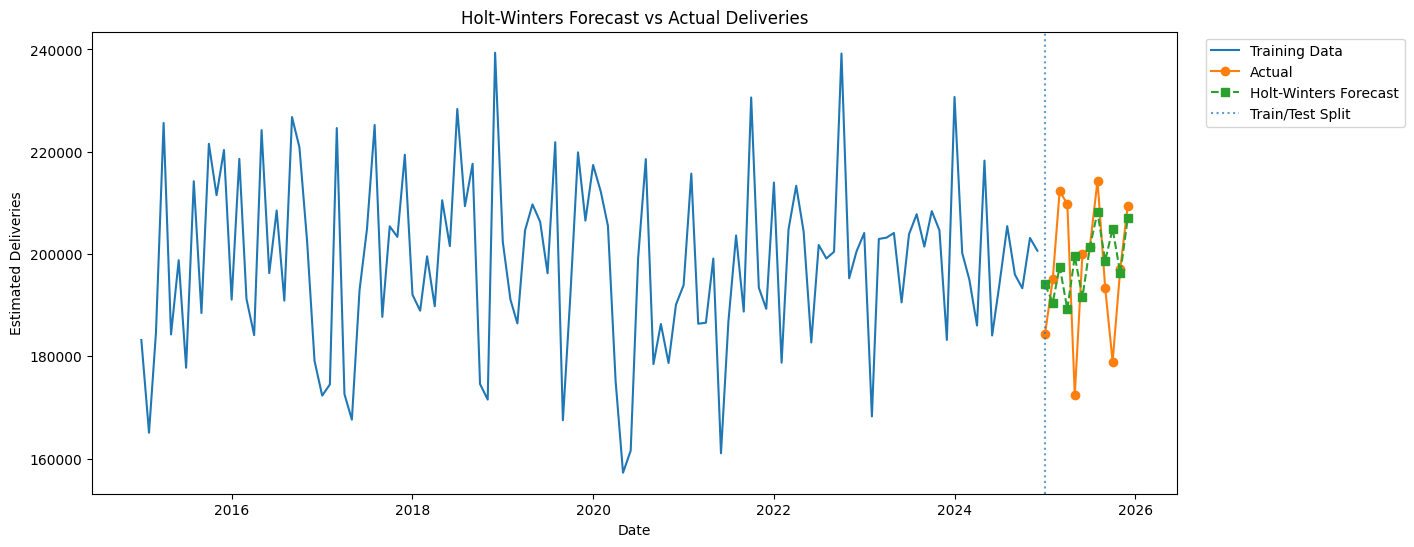

In [41]:
plt.figure(figsize=(14,6))

plt.plot(train_ts["Date"], train_ts["Estimated_Deliveries"], label="Training Data")
plt.plot(test_ts["Date"], test_ts["Estimated_Deliveries"], marker="o", label="Actual")
plt.plot(test_ts["Date"], hw_forecast, linestyle="--", marker="s", label="Holt-Winters Forecast")
plt.axvline(x=test_ts["Date"].iloc[0], linestyle=":", alpha=0.7, label="Train/Test Split")
plt.title("Holt-Winters Forecast vs Actual Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

In [42]:
future_forecast = hw_fit.forecast(12)

future_dates = pd.date_range(
    start=ts_df["Date"].max() + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)
future_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Deliveries": future_forecast.values
})
future_df

,Date,Forecast_Deliveries
0,2026-01-01,194038.352826
1,2026-02-01,190503.768497
2,2026-03-01,197531.545339
3,2026-04-01,189222.016574
4,2026-05-01,199540.875268
5,2026-06-01,191562.898952
6,2026-07-01,201352.157153
7,2026-08-01,208162.496422
8,2026-09-01,198657.202535
9,2026-10-01,204927.630309


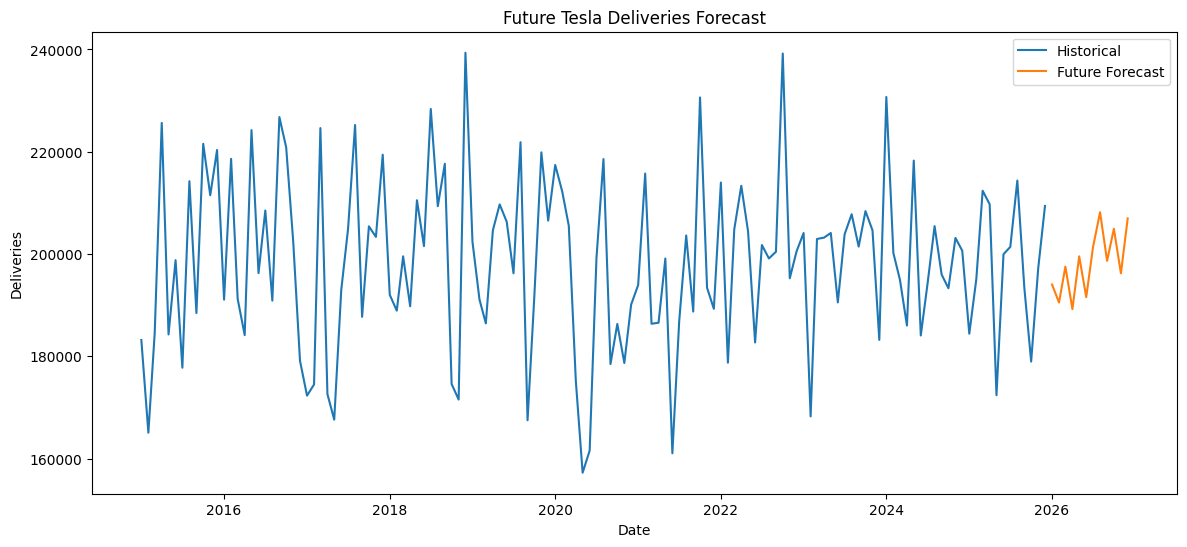

In [43]:
plt.figure(figsize=(14,6))

plt.plot( ts_df["Date"], ts_df["Estimated_Deliveries"], label="Historical")
plt.plot(future_df["Date"], future_df["Forecast_Deliveries"], label="Future Forecast")
plt.title("Future Tesla Deliveries Forecast")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()
plt.show()

### Stationarity Test (ADF)

Before applying SARIMA, the Augmented Dickey-Fuller (ADF) test was used to check whether the delivery series is stationary.

In [44]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts_df["Estimated_Deliveries"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is non-stationary")

ADF Statistic: -8.880990349502861
p-value: 1.3181396968154354e-14
Series is stationary


**ADF Test Result :**

- The ADF test produced a p-value much smaller than 0.05, indicating that the delivery series is stationary.

-  Therefore, the series is suitable for time series modeling.

### Seasonal Decomposition

The time series was decomposed into trend, seasonal, and residual components to better understand its behavior over time.

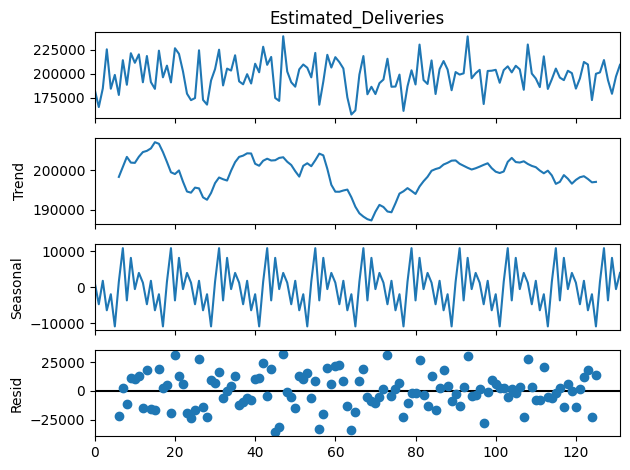

In [45]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    ts_df["Estimated_Deliveries"],
    model="additive",
    period=12
)

decomposition.plot()
plt.show()

## SARIMA Forecasting

It is tested as an alternative forecasting model and compared with Holt-Winters.

In [46]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [47]:
sarima_model = SARIMAX(
    train_ts["Estimated_Deliveries"],
    order=(1, 0, 1),          # AR=1, Diff=0, MA=1
    seasonal_order=(1, 0, 1, 12),  # Seasonal AR=1, Diff=0, MA=1, yearly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  120
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood               -1210.724
Date:                            Sun, 07 Jun 2026   AIC                           2431.448
Time:                                    17:18:32   BIC                           2444.765
Sample:                                         0   HQIC                          2436.845
                                            - 120                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8874      0.016     55.319      0.000       0.856       0.919
ma.L1         -0.9017      0.040   

In [48]:
sarima_forecast = sarima_fit.forecast(steps=len(test_ts))
sarima_mae = mean_absolute_error(test_ts["Estimated_Deliveries"], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test_ts["Estimated_Deliveries"],sarima_forecast))

print("SARIMA MAE :", round(sarima_mae,2))
print("SARIMA RMSE:", round(sarima_rmse,2))

SARIMA MAE : 15943.25
SARIMA RMSE: 19882.71


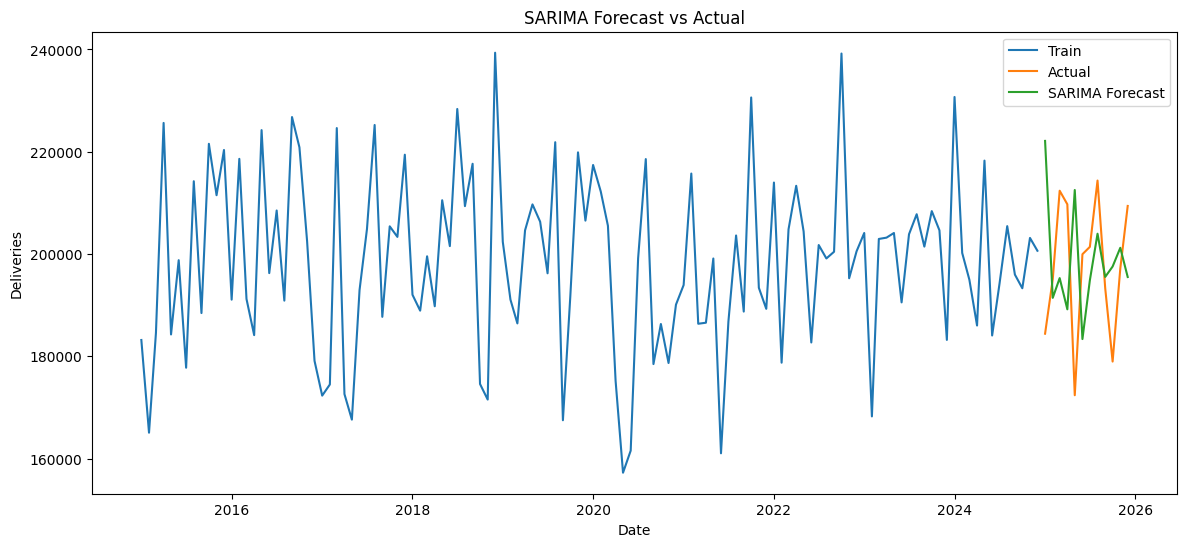

In [49]:
plt.figure(figsize=(14,6))

plt.plot(train_ts["Date"], train_ts["Estimated_Deliveries"], label="Train")
plt.plot(test_ts["Date"], test_ts["Estimated_Deliveries"], label="Actual")
plt.plot(test_ts["Date"], sarima_forecast, label="SARIMA Forecast")
plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()
plt.show()

In [50]:
forecast_results = pd.DataFrame({
    "Model": ["Holt-Winters", "SARIMA"],
    "MAE": [forecast_mae, sarima_mae],
    "RMSE": [forecast_rmse, sarima_rmse]
})

forecast_results.sort_values("RMSE")

,Model,MAE,RMSE
0,Holt-Winters,10494.593703,13871.698713
1,SARIMA,15943.249640,19882.713468


**Forecast Comparison :**
Holt-Winters achieved lower forecasting error and was selected as the final forecasting model.

# 14. Business Insights

- Production Units are the strongest predictor of Deliveries.
- XGBoost achieved the best regression performance.
- Deliveries and Production Units are highly correlated.
- Holt-Winters performed better than SARIMA for forecasting.

# 15. Conclusion

In this project:

- Data was cleaned and analyzed.
- Multiple regression models were trained.
- XGBoost achieved the best prediction performance.
- Hyperparameter tuning further improved results.
- Holt-Winters performed best for forecasting.